In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [12]:
# Upload datasets to Colab and update paths
train_path='dataset_B_training.csv'
test_path='dataset_B_testing.csv'

train_df=pd.read_csv(train_path)
test_df=pd.read_csv(test_path)

display(train_df.head())
print(train_df.shape)
print(test_df.shape)

,respondent_id,h1n1_concern,h1n1_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,...,sex,income_poverty,marital_status,rent_or_own,employment_status,census_msa,household_adults,household_children,employment_sector,h1n1_vaccine
0,1,1.0,2.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,...,Female,"<= $75,000, Above Poverty",Married,Own,Employed,"MSA, Not Principle City",2.0,1.0,science,0
1,2,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,Female,Below Poverty,Not Married,Own,Employed,Non-MSA,0.0,3.0,wholesale,0
2,3,2.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,...,Female,"> $75,000",Not Married,Own,Employed,"MSA, Principle City",0.0,0.0,education,1
3,4,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,...,Female,"<= $75,000, Above Poverty",Not Married,Rent,Not in Labor Force,Non-MSA,0.0,0.0,NaN,0
4,5,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,Female,NaN,Not Married,NaN,Unemployed,Non-MSA,3.0,0.0,NaN,0


(4756, 31)
(4749, 30)


Exploratory Data Analysis

In [13]:
# Basic EDA
train_df.info()
train_df.describe(include='all').T

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4756 entries, 0 to 4755
Data columns (total 31 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   respondent_id                4756 non-null   int64  
 1   h1n1_concern                 4741 non-null   float64
 2   h1n1_knowledge               4734 non-null   float64
 3   behavioral_antiviral_meds    4739 non-null   float64
 4   behavioral_avoidance         4729 non-null   float64
 5   behavioral_face_mask         4752 non-null   float64
 6   behavioral_wash_hands        4748 non-null   float64
 7   behavioral_large_gatherings  4747 non-null   float64
 8   behavioral_outside_home      4741 non-null   float64
 9   behavioral_touch_face        4736 non-null   float64
 10  doctor_recc_h1n1             4437 non-null   float64
 11  chronic_med_condition        4595 non-null   float64
 12  child_under_6_months         4622 non-null   float64
 13  health_worker     

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
respondent_id,4756.0,NaN,NaN,NaN,2378.5,1373.08327,1.0,1189.75,2378.5,3567.25,4756.0
h1n1_concern,4741.0,NaN,NaN,NaN,1.658933,0.892478,0.0,1.0,2.0,2.0,3.0
h1n1_knowledge,4734.0,NaN,NaN,NaN,1.30714,0.612811,0.0,1.0,1.0,2.0,2.0
behavioral_antiviral_meds,4739.0,NaN,NaN,NaN,0.057396,0.232622,0.0,0.0,0.0,0.0,1.0
behavioral_avoidance,4729.0,NaN,NaN,NaN,0.74096,0.438154,0.0,0.0,1.0,1.0,1.0
behavioral_face_mask,4752.0,NaN,NaN,NaN,0.077652,0.267651,0.0,0.0,0.0,0.0,1.0
behavioral_wash_hands,4748.0,NaN,NaN,NaN,0.842039,0.364743,0.0,1.0,1.0,1.0,1.0
behavioral_large_gatherings,4747.0,NaN,NaN,NaN,0.359385,0.479871,0.0,0.0,0.0,1.0,1.0
behavioral_outside_home,4741.0,NaN,NaN,NaN,0.341278,0.474189,0.0,0.0,0.0,1.0,1.0
behavioral_touch_face,4736.0,NaN,NaN,NaN,0.704814,0.456174,0.0,0.0,1.0,1.0,1.0


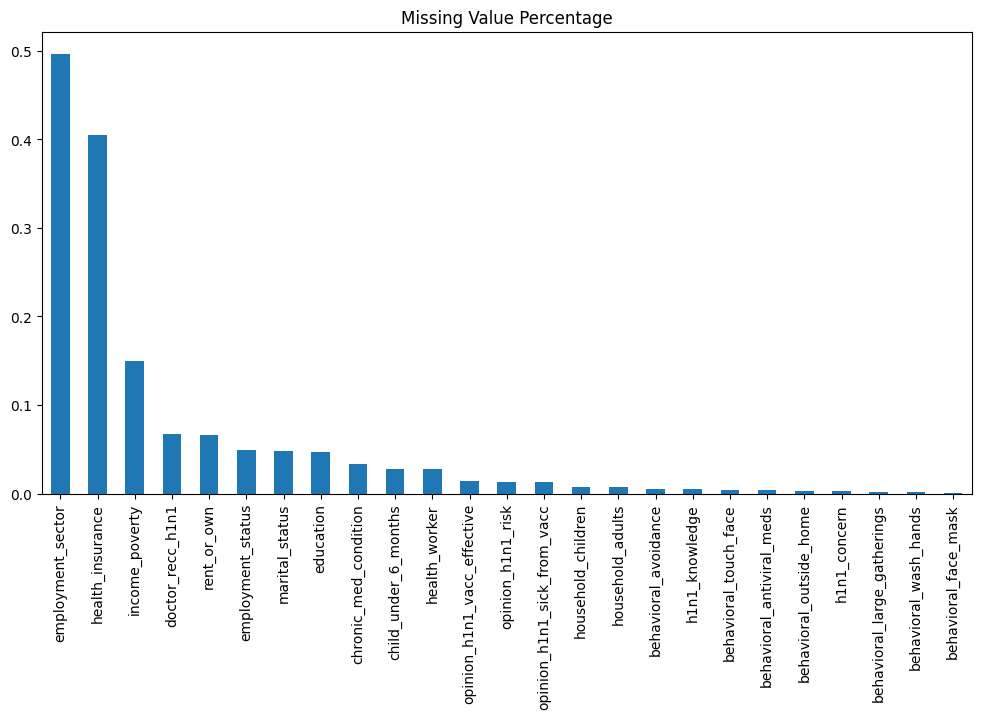

In [14]:
# Missing Values
missing=train_df.isnull().mean().sort_values(ascending=False)
plt.figure(figsize=(12,6))
missing[missing>0].plot(kind='bar')
plt.title('Missing Value Percentage')
plt.show()

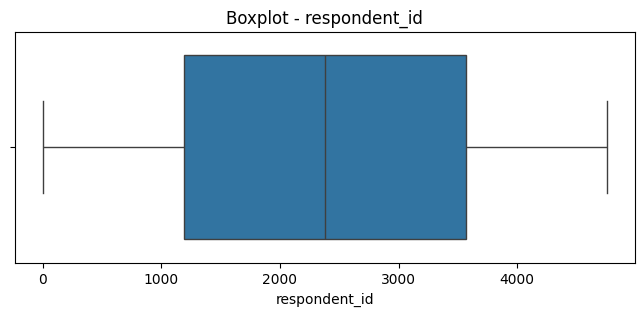

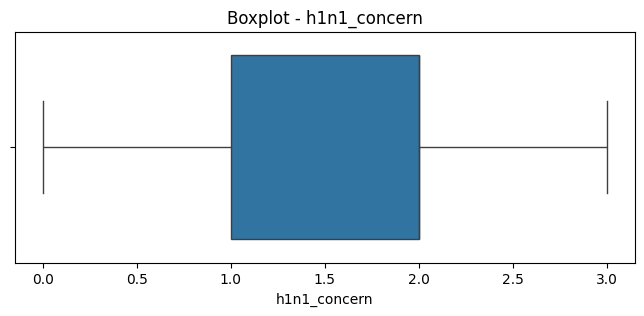

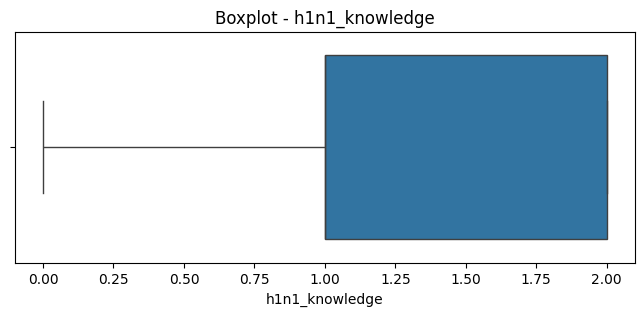

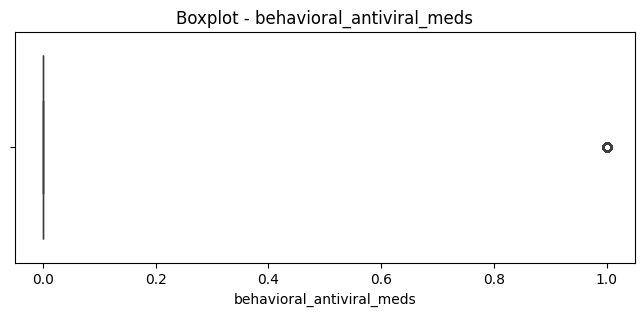

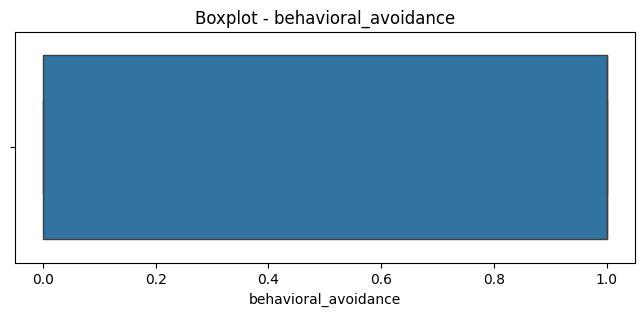

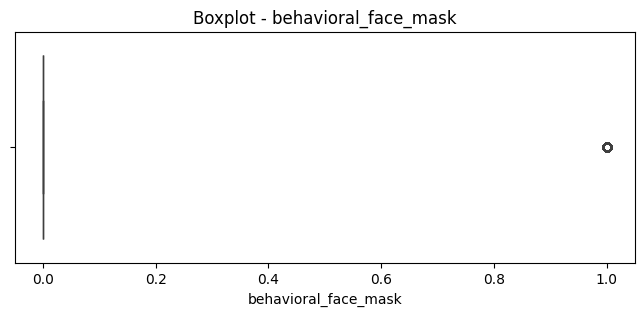

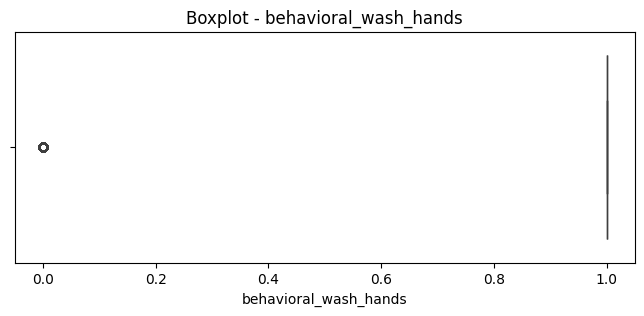

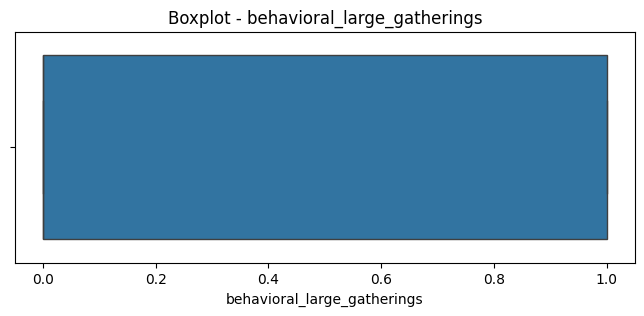

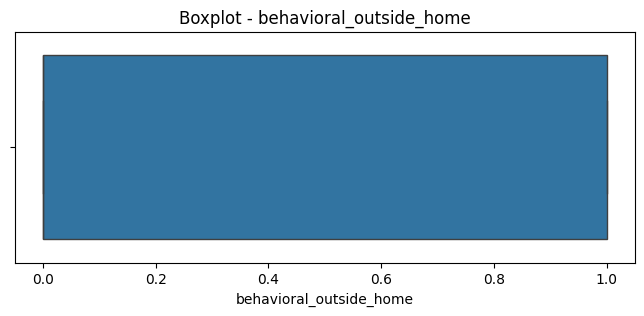

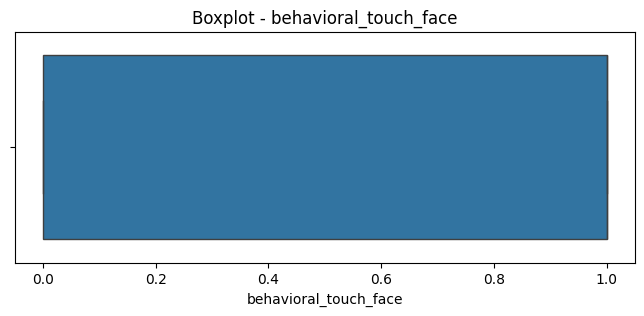

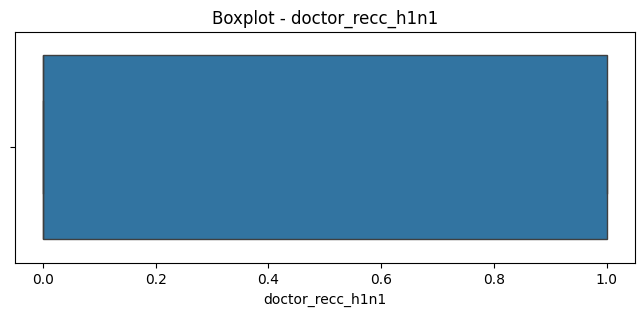

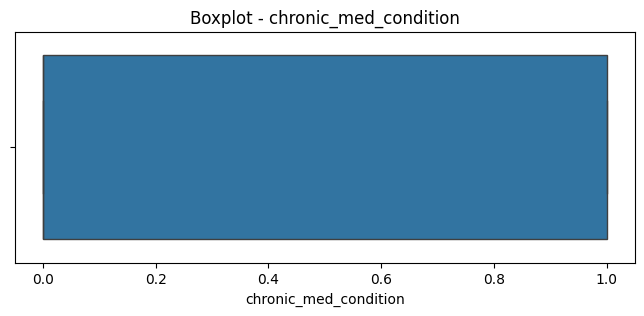

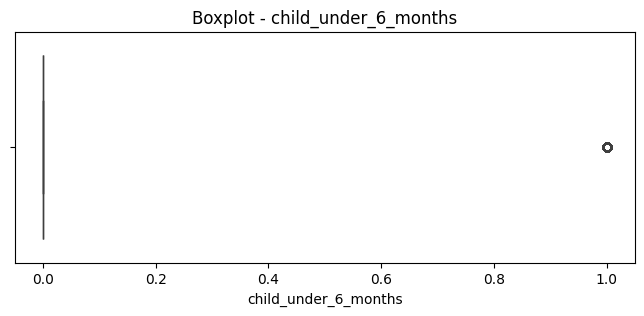

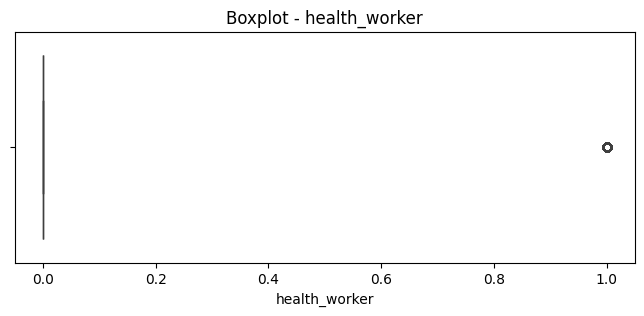

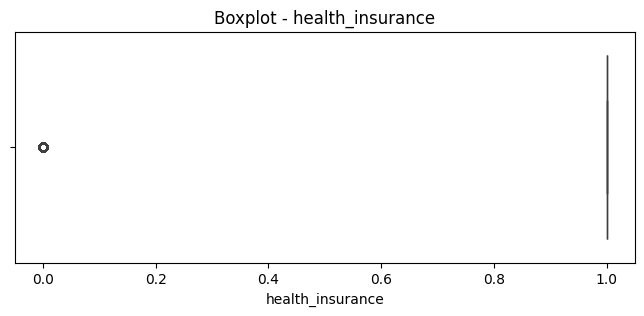

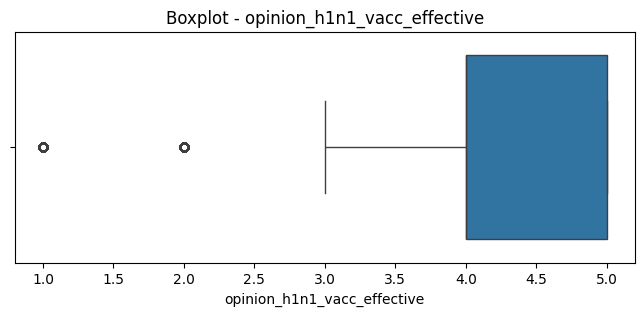

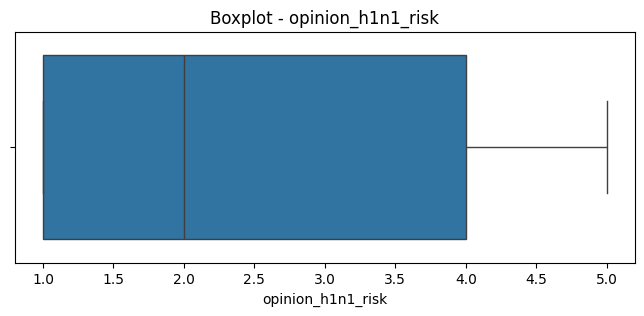

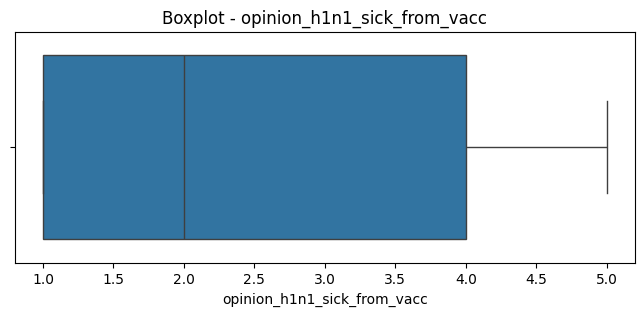

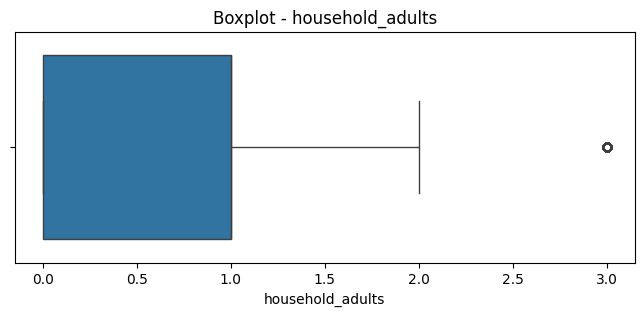

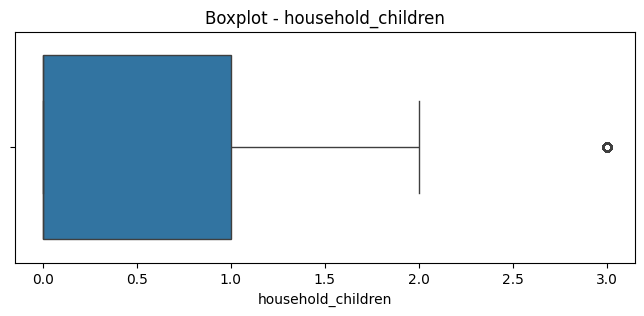

In [15]:
target = 'h1n1_vaccine'
X = train_df.drop(columns=[target])

cat_cols = X.select_dtypes(include=['object']).columns.tolist()
num_cols = [c for c in X.columns if c not in cat_cols]

for col in num_cols[:20]:

    plt.figure(figsize=(8,3))

    sns.boxplot(
        x=train_df[col]
    )

    plt.title(f"Boxplot - {col}")
    plt.show()

In [16]:
skew_df = pd.DataFrame({
    'Feature': num_cols,
    'Skewness': train_df[num_cols].skew()
})

skew_df.sort_values(
    by='Skewness',
    ascending=False
).head(20)

,Feature,Skewness
behavioral_antiviral_meds,behavioral_antiviral_meds,3.806949
behavioral_face_mask,behavioral_face_mask,3.157298
child_under_6_months,child_under_6_months,2.856946
health_worker,health_worker,2.061517
household_children,household_children,1.524739
doctor_recc_h1n1,doctor_recc_h1n1,0.924377
household_adults,household_adults,0.817273
chronic_med_condition,chronic_med_condition,0.801600
behavioral_outside_home,behavioral_outside_home,0.669728
behavioral_large_gatherings,behavioral_large_gatherings,0.586301


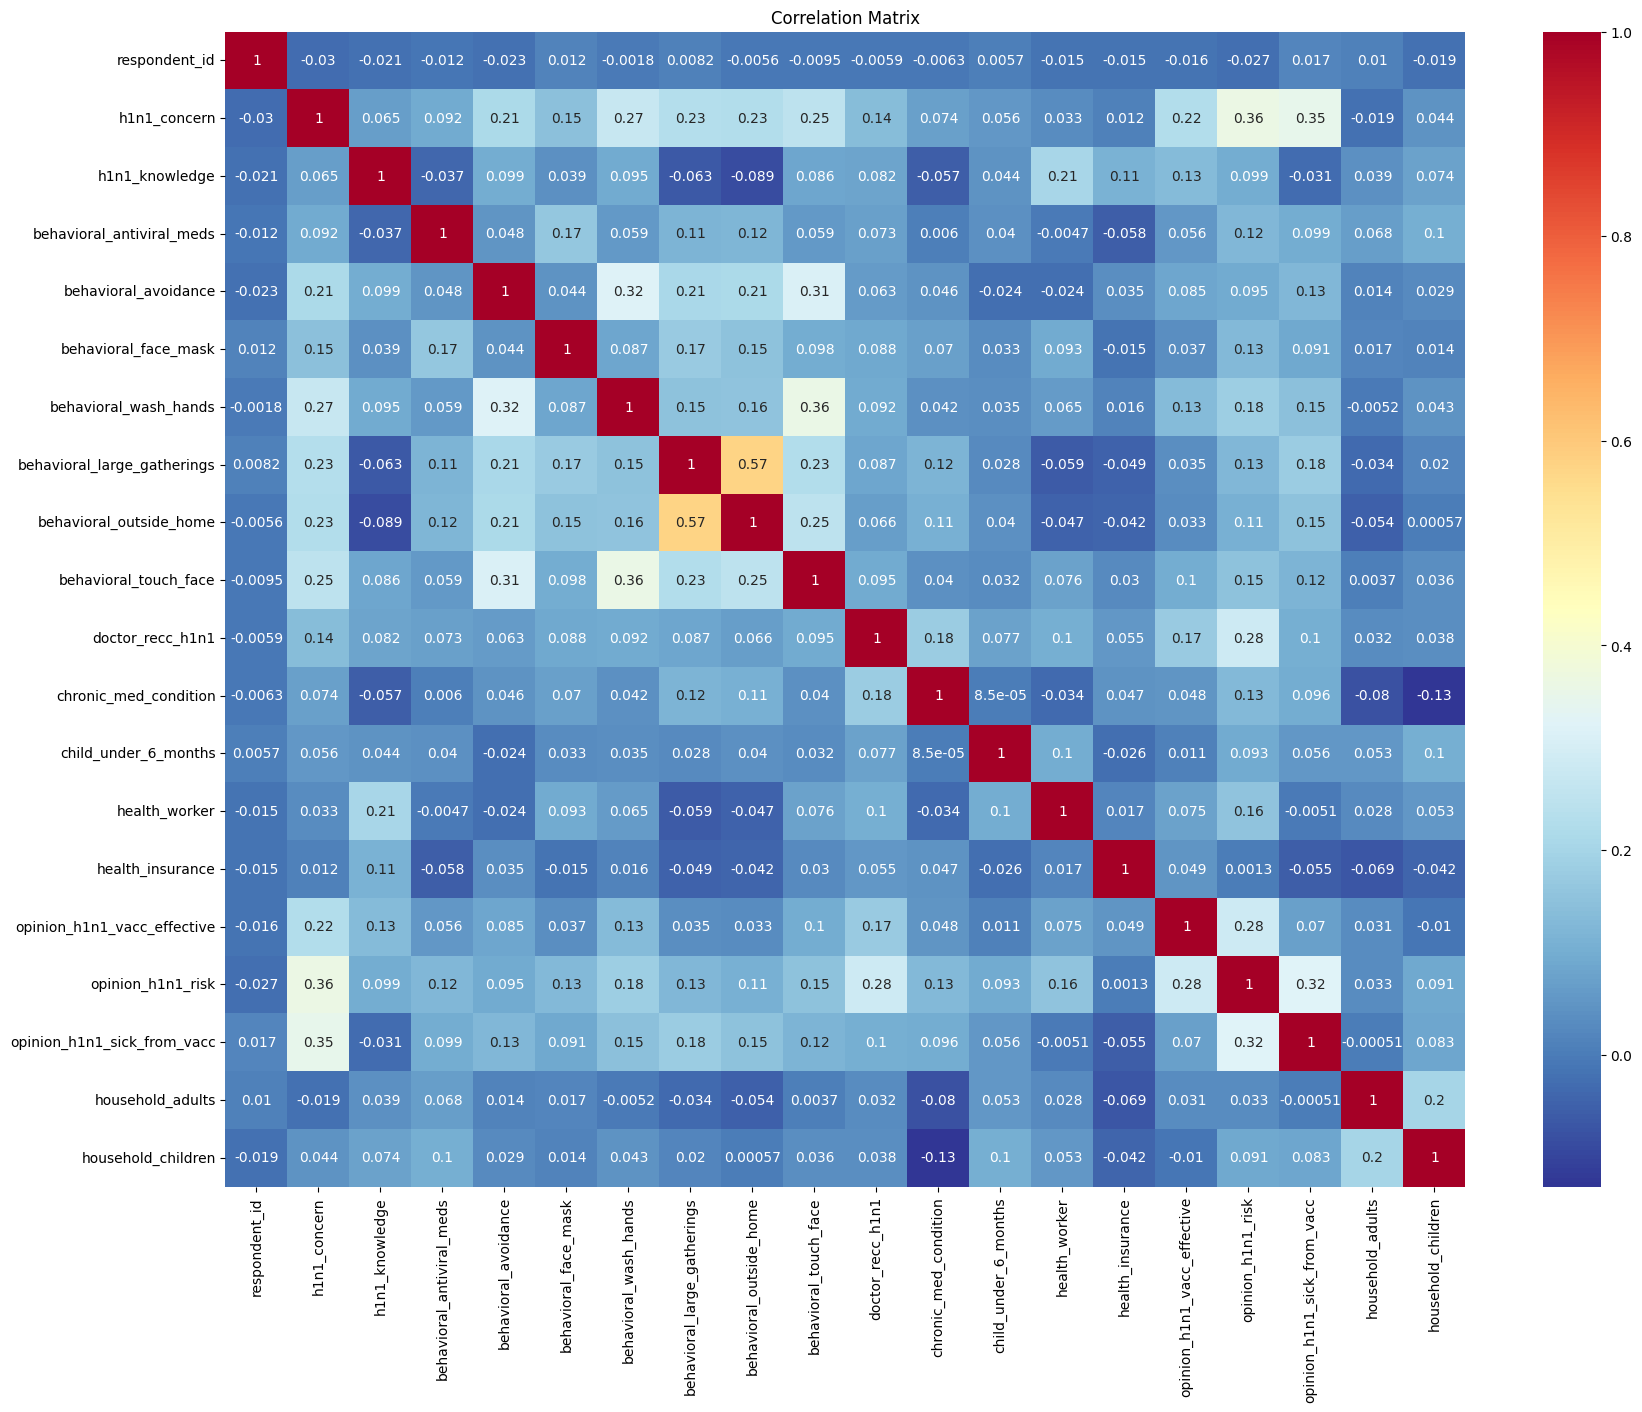

In [17]:
corr_matrix = train_df[num_cols].corr()

plt.figure(figsize=(20,15))

sns.heatmap(
    corr_matrix,
    cmap='RdYlBu_r',
    annot=True
)

plt.title("Correlation Matrix")
plt.show()

In [18]:
# Target
target='h1n1_vaccine'
X=train_df.drop(columns=[target])
y=train_df[target]

In [19]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder


Data Preprocessing


In [20]:
cat_cols=X.select_dtypes(include=['object']).columns.tolist()
num_cols=[c for c in X.columns if c not in cat_cols]

numeric_pipe=Pipeline([
 ('imputer',IterativeImputer(random_state=42,max_iter=10))
])

categorical_pipe=Pipeline([
 ('imputer',IterativeImputer(random_state=42,max_iter=10,initial_strategy='most_frequent')),
 ('encoder',OneHotEncoder(handle_unknown='ignore'))
])

preprocessor=ColumnTransformer([
 ('num',numeric_pipe,num_cols),
 ('cat',OneHotEncoder(handle_unknown='ignore'),cat_cols)
])

In [21]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score, confusion_matrix, classification_report

In [22]:
X_train,X_valid,y_train,y_valid=train_test_split(
    X,y,test_size=0.2,stratify=y,random_state=42)

rf=RandomForestClassifier(random_state=42,n_jobs=-1)

pipe=Pipeline([
 ('prep',preprocessor),
 ('model',rf)
])

In [ ]:
# Hyperparameter Tuning
params={
 'model__n_estimators':[200,300,400],
 'model__max_depth':[5,10,15,None],
 'model__min_samples_split':[2,5,10],
 'model__min_samples_leaf':[1,2,4]
}

search=RandomizedSearchCV(
 pipe,
 params,
 n_iter=20,
 scoring='f1',
 cv=5,
 random_state=42,
 n_jobs=-1
)

search.fit(X_train,y_train)
best_model=search.best_estimator_
print(search.best_params_)

In [ ]:
pred=best_model.predict(X_valid)
prob=best_model.predict_proba(X_valid)[:,1]

print('Accuracy:',accuracy_score(y_valid,pred))
print('F1:',f1_score(y_valid,pred))
print('Precision:',precision_score(y_valid,pred))
print('Recall:',recall_score(y_valid,pred))
print('ROC-AUC:',roc_auc_score(y_valid,prob))

print(classification_report(y_valid,pred))

In [ ]:
cm=confusion_matrix(y_valid,pred)
sns.heatmap(cm,annot=True,fmt='d')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
!pip install shap -q

In [ ]:
import shap

In [ ]:
Xt=best_model.named_steps['prep'].fit_transform(X_train)
rf_model=best_model.named_steps['model']

explainer=shap.TreeExplainer(rf_model)
shap_values=explainer.shap_values(Xt[:500])

shap_values_class_1 = shap_values[:, :, 1]

transformed_feature_names = best_model.named_steps['prep'].get_feature_names_out()

shap.summary_plot(shap_values_class_1, Xt[:500], feature_names=transformed_feature_names, show=False)
plt.show()

In [ ]:
import joblib

In [ ]:
# Train on Full Dataset
best_model.fit(X,y)
joblib.dump(best_model,'h1n1_random_forest_model.pkl')

In [ ]:
# Predictions
test_pred=best_model.predict(test_df)

submission=pd.DataFrame({
 'respondent_id':test_df['respondent_id'],
 'h1n1_vaccine':test_pred
})

submission.to_csv('h1n1_predictions.csv',index=False)
submission.head()